In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb

df = pd.read_parquet("../data/processed/sales_ca1_clean.parquet")
df = df.sort_values(["item_id", "date"]).reset_index(drop=True)
print(df.shape)

(4788267, 17)


In [3]:
g = df.groupby("item_id")["sales"]

# Ventes passées (au moins 28 jours avant)
df["vente_il_y_a_28j"] = g.shift(28)
df["vente_il_y_a_35j"] = g.shift(35)
df["moyenne_7j"]  = g.transform(lambda s: s.shift(28).rolling(7).mean())
df["moyenne_28j"] = g.transform(lambda s: s.shift(28).rolling(28).mean())

# Calendrier
df["jour_semaine"] = df["date"].dt.dayofweek
df["mois"]         = df["date"].dt.month
df["evenement"]    = df["event_name_1"].notna().astype(int)

df[["date", "item_id", "sales", "vente_il_y_a_28j", "moyenne_28j", "jour_semaine"]].iloc[60:66]


,date,item_id,sales,vente_il_y_a_28j,moyenne_28j,jour_semaine
60,2011-03-30,FOODS_1_001,0,1.0,1.357143,2
61,2011-03-31,FOODS_1_001,0,7.0,1.535714,3
62,2011-04-01,FOODS_1_001,0,1.0,1.571429,4
63,2011-04-02,FOODS_1_001,0,2.0,1.571429,5
64,2011-04-03,FOODS_1_001,0,3.0,1.678571,6
65,2011-04-04,FOODS_1_001,4,0.0,1.678571,0


In [4]:
def wape(vrai, prevu):
    return np.abs(vrai - prevu).sum() / vrai.sum()

def biais(vrai, prevu):
    return (prevu.sum() - vrai.sum()) / vrai.sum()

In [5]:
debut_test = pd.Timestamp("2016-02-29")
fin_test   = pd.Timestamp("2016-03-27")

train = df[(df["date"] >= "2013-01-01") & (df["date"] < debut_test)]
test  = df[(df["date"] >= debut_test) & (df["date"] <= fin_test)].copy()

features_A = ["vente_il_y_a_28j", "vente_il_y_a_35j", "moyenne_7j", "moyenne_28j"]

modele_A = lgb.LGBMRegressor(objective="tweedie", n_estimators=300,
                             learning_rate=0.05, verbose=-1)
modele_A.fit(train[features_A], train["sales"])

test["prevu_A"] = modele_A.predict(test[features_A])

totaux = test.groupby("item_id")[["sales", "prevu_A"]].sum()
print("Modèle A | WAPE jour :", round(wape(test["sales"], test["prevu_A"]) * 100, 1), "%",
      "| WAPE total 28 j :", round(wape(totaux["sales"], totaux["prevu_A"]) * 100, 1), "%",
      "| Biais :", round(biais(test["sales"], test["prevu_A"]) * 100, 1), "%")

Modèle A | WAPE jour : 78.3 % | WAPE total 28 j : 30.6 % | Biais : -3.2 %


In [6]:
features_B = features_A + ["sell_price"]
features_C = features_B + ["jour_semaine", "mois", "evenement", "snap_CA"]

for nom, feats in [("B", features_B), ("C", features_C)]:
    modele = lgb.LGBMRegressor(objective="tweedie", n_estimators=300,
                               learning_rate=0.05, verbose=-1)
    modele.fit(train[feats], train["sales"])
    test["prevu_" + nom] = modele.predict(test[feats])

    tot = test.groupby("item_id")[["sales", "prevu_" + nom]].sum()
    print("Modèle", nom,
          "| WAPE jour :", round(wape(test["sales"], test["prevu_" + nom]) * 100, 1), "%",
          "| WAPE total 28 j :", round(wape(tot["sales"], tot["prevu_" + nom]) * 100, 1), "%",
          "| Biais :", round(biais(test["sales"], test["prevu_" + nom]) * 100, 1), "%")

Modèle B | WAPE jour : 77.9 % | WAPE total 28 j : 30.2 % | Biais : -4.2 %
Modèle C | WAPE jour : 76.7 % | WAPE total 28 j : 30.1 % | Biais : -2.2 %


In [7]:
def construire(origine):
    # Ventes connues : les 56 jours AVANT l'origine
    hist = df[(df["date"] < origine) & (df["date"] >= origine - pd.Timedelta(days=56))]

    f = hist.groupby("item_id")["sales"].mean().rename("moy_56j").to_frame()
    f["moy_28j"] = hist[hist["date"] >= origine - pd.Timedelta(days=28)].groupby("item_id")["sales"].mean()
    f["moy_7j"]  = hist[hist["date"] >= origine - pd.Timedelta(days=7)].groupby("item_id")["sales"].mean()
    f["part_jours_vente"] = (hist["sales"] > 0).groupby(hist["item_id"]).mean()

    moy_jour = (hist.groupby(["item_id", "jour_semaine"])["sales"].mean()
                    .rename("moy_meme_jour").reset_index())

    # Les 28 jours à prévoir
    cible = df[(df["date"] >= origine) & (df["date"] < origine + pd.Timedelta(days=28))]
    cible = cible[["item_id", "date", "sales", "sell_price",
                   "jour_semaine", "mois", "evenement", "snap_CA"]].copy()

    cible = cible.merge(f.reset_index(), on="item_id", how="left")
    cible = cible.merge(moy_jour, on=["item_id", "jour_semaine"], how="left")
    cible["horizon"] = (cible["date"] - origine).dt.days + 1
    return cible

In [8]:
# 50 "lundis matin" dans le passé, un toutes les 2 semaines, AVANT le test
origines = pd.date_range(end=debut_test - pd.Timedelta(days=28), periods=50, freq="14D")

train2 = pd.concat([construire(o) for o in origines])
test2  = construire(debut_test)

features_v2 = ["moy_7j", "moy_28j", "moy_56j", "part_jours_vente", "moy_meme_jour",
               "horizon", "sell_price", "jour_semaine", "mois", "evenement", "snap_CA"]

modele_v2 = lgb.LGBMRegressor(objective="tweedie", n_estimators=300,
                              learning_rate=0.05, verbose=-1)
modele_v2.fit(train2[features_v2], train2["sales"])
test2["prevu_v2"] = modele_v2.predict(test2[features_v2])

tot = test2.groupby("item_id")[["sales", "prevu_v2"]].sum()
print("Modèle C v2 | WAPE jour :", round(wape(test2["sales"], test2["prevu_v2"]) * 100, 1), "%",
      "| WAPE total 28 j :", round(wape(tot["sales"], tot["prevu_v2"]) * 100, 1), "%",
      "| Biais :", round(biais(test2["sales"], test2["prevu_v2"]) * 100, 1), "%")

Modèle C v2 | WAPE jour : 73.7 % | WAPE total 28 j : 27.1 % | Biais : -1.7 %


In [9]:
debut_test_2 = pd.Timestamp("2016-03-28")

origines_2 = pd.date_range(end=debut_test_2 - pd.Timedelta(days=28), periods=50, freq="14D")
train_2 = pd.concat([construire(o) for o in origines_2])
test_2  = construire(debut_test_2)

modele_2 = lgb.LGBMRegressor(objective="tweedie", n_estimators=300,
                             learning_rate=0.05, verbose=-1)
modele_2.fit(train_2[features_v2], train_2["sales"])
test_2["prevu_v2"] = modele_2.predict(test_2[features_v2])

tot_2 = test_2.groupby("item_id")[["sales", "prevu_v2"]].sum()
print("Test 2 | WAPE jour :", round(wape(test_2["sales"], test_2["prevu_v2"]) * 100, 1), "%",
      "| WAPE total 28 j :", round(wape(tot_2["sales"], tot_2["prevu_v2"]) * 100, 1), "%",
      "| Biais :", round(biais(test_2["sales"], test_2["prevu_v2"]) * 100, 1), "%")

Test 2 | WAPE jour : 73.0 % | WAPE total 28 j : 25.9 % | Biais : 1.4 %


In [10]:
infos = df[["item_id", "dept_id", "cat_id"]].drop_duplicates()
liste_rayons = sorted(df["dept_id"].unique())
liste_categories = sorted(df["cat_id"].unique())

def construire_v3(origine):
    cible = construire(origine)
    hist = df[(df["date"] < origine) & (df["date"] >= origine - pd.Timedelta(days=56))]

    # Prix : plus bas que d'habitude ?
    prix_moy = hist.groupby("item_id")["sell_price"].mean().rename("prix_moy_56j").reset_index()
    cible = cible.merge(prix_moy, on="item_id", how="left")
    cible["prix_relatif"] = cible["sell_price"] / cible["prix_moy_56j"]

    # Tendance : dernière semaine comparée au dernier mois
    cible["tendance"] = cible["moy_7j"] / (cible["moy_28j"] + 0.1)

    # Jours depuis la dernière vente
    derniere_vente = hist[hist["sales"] > 0].groupby("item_id")["date"].max()
    cible["jours_sans_vente"] = (origine - cible["item_id"].map(derniere_vente)).dt.days

    # Rayon et catégorie
    cible = cible.merge(infos, on="item_id", how="left")
    cible["dept_id"] = pd.Categorical(cible["dept_id"], categories=liste_rayons)
    cible["cat_id"]  = pd.Categorical(cible["cat_id"],  categories=liste_categories)
    return cible

In [11]:
features_v3 = features_v2 + ["prix_relatif", "tendance", "jours_sans_vente", "dept_id", "cat_id"]

for nom, debut in [("Test 1", pd.Timestamp("2016-02-29")), ("Test 2", pd.Timestamp("2016-03-28"))]:
    origines = pd.date_range(end=debut - pd.Timedelta(days=28), periods=50, freq="14D")
    tr = pd.concat([construire_v3(o) for o in origines])
    te = construire_v3(debut)

    m = lgb.LGBMRegressor(objective="tweedie", n_estimators=300,
                          learning_rate=0.05, verbose=-1)
    m.fit(tr[features_v3], tr["sales"])
    te["prevu"] = m.predict(te[features_v3])

    tot = te.groupby("item_id")[["sales", "prevu"]].sum()
    print(nom, "| WAPE jour :", round(wape(te["sales"], te["prevu"]) * 100, 1), "%",
          "| WAPE total 28 j :", round(wape(tot["sales"], tot["prevu"]) * 100, 1), "%",
          "| Biais :", round(biais(te["sales"], te["prevu"]) * 100, 1), "%")

Test 1 | WAPE jour : 72.9 % | WAPE total 28 j : 26.5 % | Biais : -1.8 %
Test 2 | WAPE jour : 72.8 % | WAPE total 28 j : 25.7 % | Biais : 1.6 %


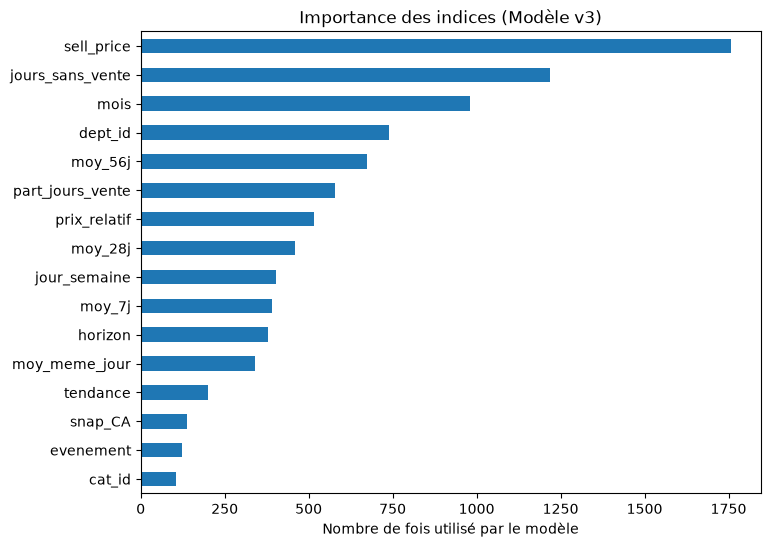

In [12]:
importance = pd.Series(m.feature_importances_, index=features_v3).sort_values()

importance.plot(kind="barh", figsize=(8, 6), title="Importance des indices (Modèle v3)")
import matplotlib.pyplot as plt
plt.xlabel("Nombre de fois utilisé par le modèle")
plt.show()

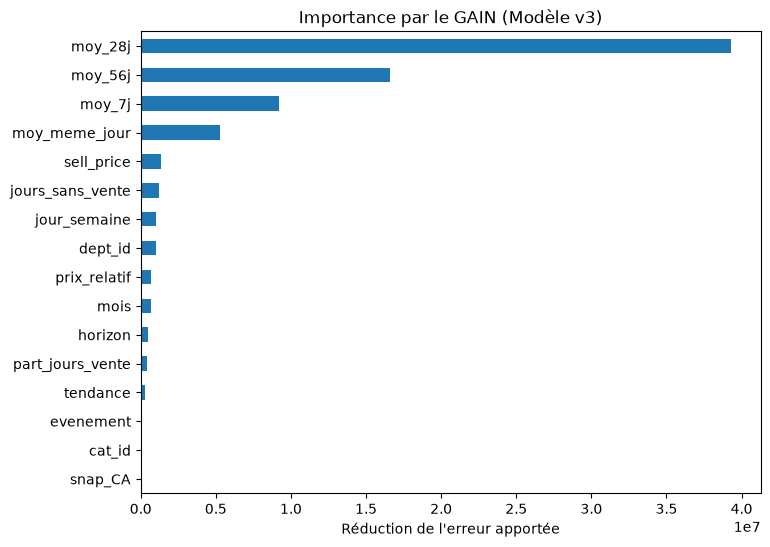

In [13]:
importance_gain = pd.Series(
    m.booster_.feature_importance(importance_type="gain"),
    index=features_v3
).sort_values()

importance_gain.plot(kind="barh", figsize=(8, 6), title="Importance par le GAIN (Modèle v3)")
plt.xlabel("Réduction de l'erreur apportée")
plt.show()
